# Text Analysis of Public Submissions on the 2025 Australian Federal Election Inquiry


## Introduction

This report analyses public submissions made to the Australian parliamentary inquiry into the conduct of the 2025 federal election. The goal of this analysis is to explore patterns, themes, and opinions expressed within the submissions using Natural Language Processing (NLP) techniques. By applying text preprocessing, word frequency analysis, sentiment analysis, and topic modelling, this study aims to identify the main topics discussed and the overall sentiment of contributors. The findings help provide insight into public concerns and perspectives regarding the electoral process.

## Install libraries

In [1]:
!pip install PyPDF2
!pip install nltk
!pip install gensim
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.7 MB/s eta 0:00:00


## Import libraries

In [ ]:
import os
from PyPDF2 import PdfReader
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import numpy as np
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer


## Data Ingestion

The dataset used in this analysis consists of public submissions made to the parliamentary inquiry into the conduct of the 2025 federal election in Australia. These submissions are provided as PDF documents. To analyse the text data, the PDFs were first extracted and converted into plain text using Python libraries. Each document was processed and stored for further analysis. The extracted text was then combined to form a corpus that could be analysed using various natural language processing techniques.

 Dataset Location

The dataset is stored in Google Drive for development in Google Colab.  
If the notebook is run locally, the folder path should be updated to the dataset location on the local machine.

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    folder_path = "/content/drive/MyDrive/submissions_2025 federal election"
except:
    # If running outside Colab, change this path to the dataset location
    folder_path = "submissions_2025_federal_election"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder_path = "/content/drive/MyDrive/submissions_2025 federal election"

texts = []

for file in os.listdir(folder_path):
    if file.endswith(".pdf"):
        reader = PdfReader(os.path.join(folder_path, file))
        text = ""

        for page in reader.pages:
            if page.extract_text():
                text += page.extract_text()

        texts.append(text)

all_text = " ".join(texts)

print("Total documents:", len(texts))


[0, IndirectObject(295, 0, 133616420111328)]
[0, IndirectObject(298, 0, 133616420111328)]
[0, IndirectObject(301, 0, 133616420111328)]
[0, IndirectObject(295, 0, 133616420111328)]
[0, IndirectObject(298, 0, 133616420111328)]
[0, IndirectObject(301, 0, 133616420111328)]


Total documents: 299


## Exploratory data analysis

Exploratory Data Analysis (EDA) was conducted to gain an initial understanding of the dataset and its textual characteristics before applying further natural language processing techniques. This step involved examining the number of documents, the overall length of the text, and the distribution of words within the corpus. These preliminary insights help identify patterns, potential issues in the data, and guide the subsequent preprocessing and analysis steps.



In [ ]:
num_documents = len(texts)


total_characters = len(all_text)


total_words = len(all_text.split())

print("Number of documents:", num_documents)
print("Total characters in corpus:", total_characters)
print("Total words in corpus:", total_words)

Number of documents: 299
Total characters in corpus: 3967964
Total words in corpus: 604788


**Document length analysis**

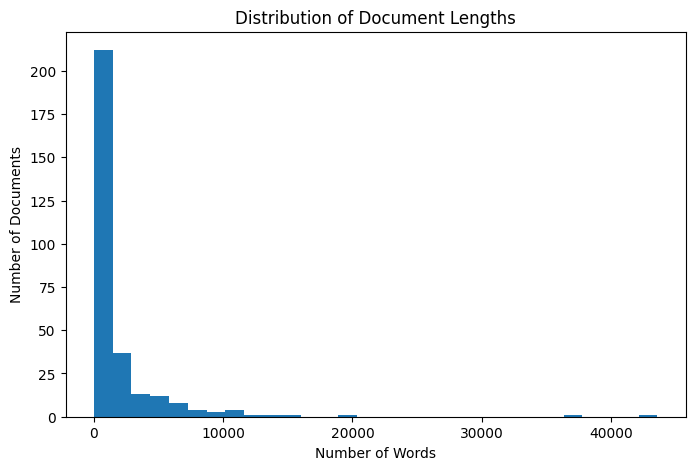

In [ ]:
doc_lengths = [len(text.split()) for text in texts]

plt.figure(figsize=(8,5))
plt.hist(doc_lengths, bins=30)
plt.title("Distribution of Document Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Documents")
plt.show()

The histogram illustrates the distribution of document lengths across the submissions. It shows that some submissions are relatively short while others are much longer and contain more detailed content. This variation reflects the diverse nature of contributors, including individuals, organizations, and institutions providing different levels of detail in their responses.

**Word Frequency Analysis (Before Preprocessing)**

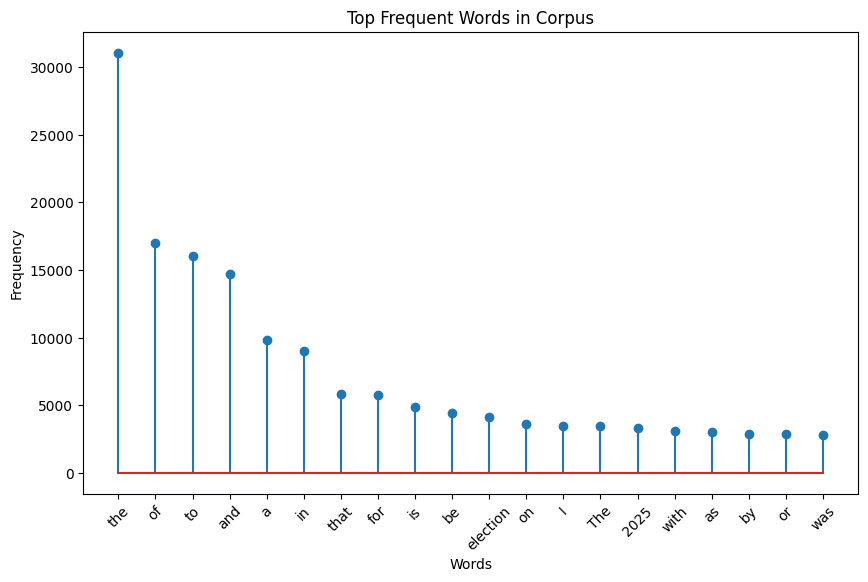

In [ ]:
words = all_text.split()
word_counts = Counter(words)

top_words = word_counts.most_common(20)

labels = [w[0] for w in top_words]
values = [w[1] for w in top_words]

plt.figure(figsize=(10,6))

plt.stem(labels, values)
plt.xticks(rotation=45)

plt.title("Top Frequent Words in Corpus")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

The stem plot shows the most frequently occurring words in the raw text corpus collected from the election submissions. As expected, the most common terms include function words such as “the”, “of”, “to”, and “and”. These words appear frequently in almost all English texts because they play a grammatical role rather than conveying specific meaning. The presence of these words at the top of the frequency list indicates that the corpus has not yet undergone preprocessing steps such as stopword removal. Nevertheless, this visualization provides an initial understanding of the vocabulary distribution in the dataset and highlights the need for text preprocessing techniques to focus the analysis on more meaningful and topic-related terms.

**Document Length Distribution Analysis**

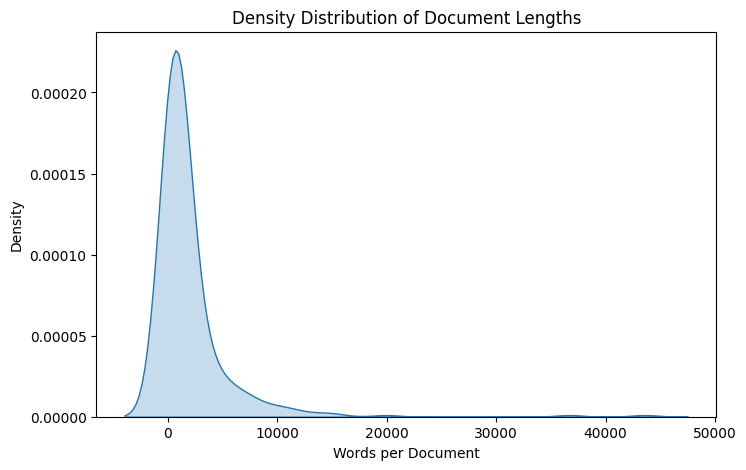

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(doc_lengths, fill=True)
plt.title("Density Distribution of Document Lengths")
plt.xlabel("Words per Document")
plt.ylabel("Density")
plt.show()

The density plot provides a smooth representation of how document lengths are distributed across the submission corpus. Most of the submissions are concentrated within the lower word-count range, indicating that many contributors submitted relatively short responses. As the word count increases, the density gradually decreases, showing that fewer documents contain very large amounts of text. The long tail on the right side of the distribution suggests that a small number of submissions are significantly longer, likely representing more detailed reports or institutional responses. Overall, this visualization confirms that the dataset is right-skewed, where a majority of documents are short while only a few are extremely long.

**Word Length Distribution**

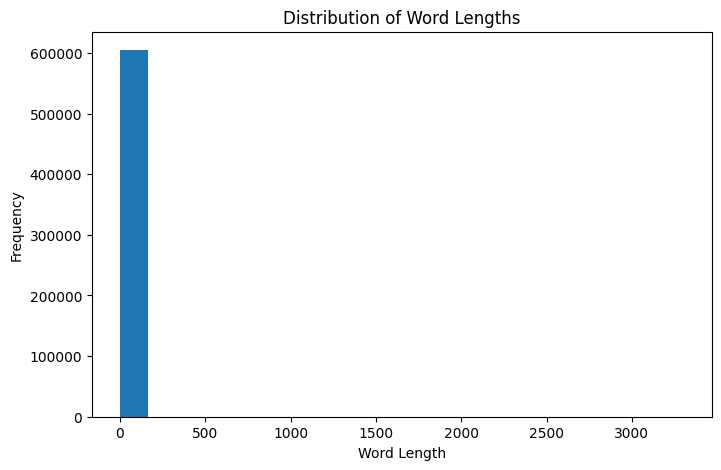

In [ ]:
word_lengths = [len(word) for word in all_text.split()]

plt.figure(figsize=(8,5))
plt.hist(word_lengths, bins=20)
plt.title("Distribution of Word Lengths")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.show()

This histogram shows the distribution of word lengths across the entire text corpus. The majority of words fall within the lower length range, indicating that most words used in the dataset are relatively short. This is expected in natural language text, as common words such as articles, prepositions, and conjunctions typically consist of only a few characters. The graph also shows that very long words occur much less frequently, which results in a strong concentration of observations on the left side of the distribution. Overall, this visualization highlights the typical structure of written language where shorter words dominate the vocabulary while longer words appear only occasionally.

**Average document length**

In [ ]:
avg_length = np.mean(doc_lengths)

print("Average document length:", avg_length)

Average document length: 2022.7023411371238


The average document length provides an overview of how detailed the submissions tend to be. A higher average suggests that many contributors provided comprehensive explanations or policy suggestions in their submissions.

**Word Frequency Heatmap**

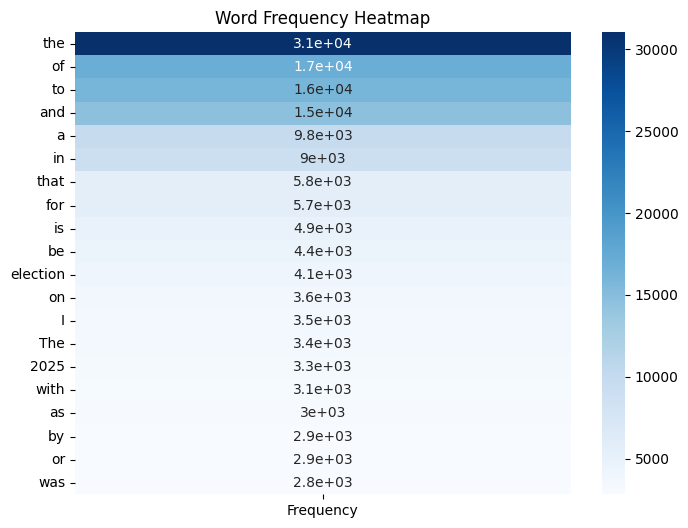

In [ ]:
data = pd.DataFrame(top_words, columns=["Word","Frequency"])

plt.figure(figsize=(8,6))

sns.heatmap(data[["Frequency"]], annot=True, cmap="Blues", yticklabels=data["Word"])

plt.title("Word Frequency Heatmap")

plt.show()

The heatmap visualizes the frequency of the most common words in the text corpus using a color gradient. Darker shades represent words with higher frequencies, while lighter shades indicate lower frequencies among the top words. From the visualization, it is clear that words such as “the”, “of”, “to”, and “and” appear much more frequently than other terms. These are common stopwords that naturally occur often in English text. The heatmap helps quickly highlight which words dominate the corpus and provides an intuitive way to compare their frequencies. This observation also suggests the importance of preprocessing steps such as stopword removal and normalization before applying further natural language processing techniques.

**Word Proportion Analysis**

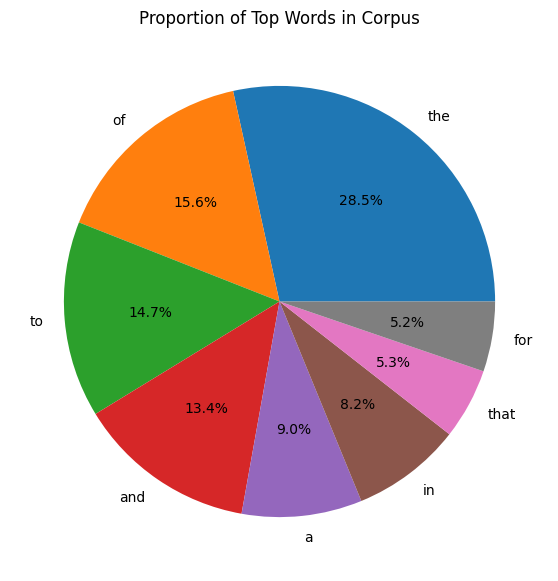

In [ ]:
labels = [w[0] for w in top_words[:8]]
values = [w[1] for w in top_words[:8]]

plt.figure(figsize=(7,7))

plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Proportion of Top Words in Corpus")

plt.show()

The pie chart illustrates the proportional contribution of the most frequent words within the corpus. Each segment represents how much each word contributes relative to the other top words. From the visualization, it can be observed that the word “the” occupies the largest proportion, followed by words such as “of”, “to”, and “and”. These are common stopwords in English and typically appear very frequently in textual data. The chart highlights that a small number of common words account for a large portion of the overall word usage in the dataset. This pattern is typical in natural language corpora and further indicates the need for preprocessing techniques such as stopword removal before performing deeper text analysis or modeling.

**Document Length Distribution (Violin Plot)**

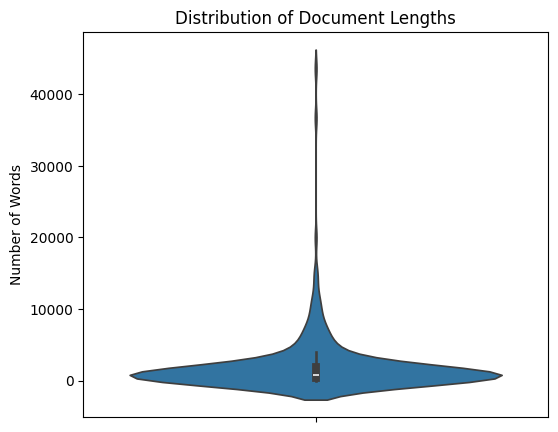

In [ ]:
doc_lengths = [len(text.split()) for text in texts]

plt.figure(figsize=(6,5))

sns.violinplot(y=doc_lengths)

plt.title("Distribution of Document Lengths")

plt.ylabel("Number of Words")

plt.show()

The violin plot provides a detailed visualization of the distribution of document lengths in the dataset. It combines elements of a box plot and a density plot to show both the spread and concentration of values. The wider sections of the violin represent ranges where many documents have similar word counts, while the narrower areas indicate fewer observations. From the plot, it is evident that most submissions contain a relatively moderate number of words, as shown by the wider region near the lower part of the distribution. The long thin extension toward the top indicates that only a small number of documents are extremely long. This confirms that the dataset is highly skewed, with most documents being shorter while a few contain substantially more content.

### 1. Basic Analysis

This section performs the fundamental analysis of the parliamentary submissions dataset to better understand the textual content before applying advanced natural language processing techniques. The main objective is to examine the basic characteristics of the corpus, including word usage patterns and the most frequently occurring terms across all submissions.

By analysing word frequencies and common vocabulary within the dataset, it becomes possible to identify dominant themes and commonly discussed topics in the submissions. These initial insights help provide a clearer understanding of the structure of the text data and highlight patterns that may be important for further analysis.

Additionally, this step supports the preprocessing stage by revealing the presence of common stopwords and repetitive terms that may need to be removed or normalized before applying more sophisticated NLP methods. Overall, the basic analysis serves as an essential foundation for deeper text analysis and helps guide the subsequent stages of the project.

### 1.1 Pre-processing

Pre-processing was carried out to clean and standardise the raw text data before further analysis. This step is important because the extracted text contains punctuation, common stopwords, and different grammatical forms of the same word, which can add noise to the results. To improve the quality of the analysis, the text was converted to lowercase, punctuation and non-alphabetic tokens were removed, stopwords were excluded, and lemmatization was applied. These steps help ensure that the analysis focuses on meaningful terms and reduces unnecessary variation in the vocabulary.

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# convert all text to lowercase and split into words
raw_words = all_text.lower().split()

# initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# preprocess words
processed_words = []

for word in raw_words:
    # remove punctuation around the word
    word = word.strip(string.punctuation)

    # keep only alphabetic words and remove stopwords
    if word.isalpha() and word not in stop_words:
        # lemmatize the word
        lemma = lemmatizer.lemmatize(word)
        processed_words.append(lemma)

print("Total words after preprocessing:", len(processed_words))
print("Sample processed words:", processed_words[:20])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Total words after preprocessing: 307036
Sample processed words: ['monica', 'sammon', 'committee', 'em', 'rep', 'subject', 'inquiry', 'federal', 'election', 'date', 'tuesday', 'september', 'pm', 'writing', 'make', 'small', 'submission', 'inquiry', 'federal', 'election']


The preprocessing pipeline was completed in four main stages. First, all text was converted to lowercase so that words such as “Election” and “election” would be treated as the same term. Second, punctuation was removed and only alphabetic words were retained to avoid including symbols, numbers, and formatting noise from the PDF files. Third, English stopwords were removed because these words occur frequently but do not contribute much to the meaning of the text. Finally, lemmatization was applied so that different grammatical forms of the same word could be reduced to a common base form. This produced a cleaner and more meaningful set of words for further analysis.

In [ ]:
processed_counts = Counter(processed_words)
print(processed_counts.most_common(20))

[('election', 6329), ('federal', 3220), ('submission', 2882), ('party', 2741), ('vote', 2569), ('electoral', 2523), ('voter', 2431), ('e', 2273), ('inquiry', 2265), ('candidate', 2237), ('would', 1882), ('aec', 1712), ('political', 1697), ('voting', 1659), ('number', 1641), ('australian', 1504), ('volunteer', 1421), ('polling', 1371), ('term', 1259), ('one', 1236)]


The most common words in the cleaned corpus were examined after preprocessing. These results highlight the key terms that appear frequently across submissions and provide an initial indication of the major topics discussed in the dataset.

### 1.2 Word frequencies [...]

Word frequency analysis was conducted to identify the most common terms appearing in the submissions after preprocessing. By examining the most frequent words, it becomes possible to understand the dominant topics discussed across the parliamentary submissions. Removing stopwords ensures that the analysis focuses on meaningful content words rather than common grammatical terms.

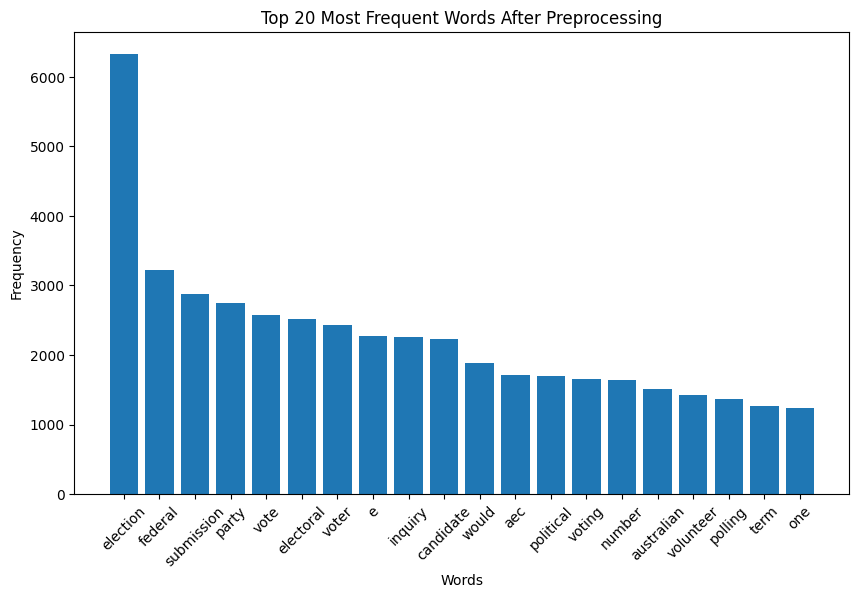

In [ ]:
processed_counts = Counter(processed_words)
top_processed_words = processed_counts.most_common(20)

labels = [w[0] for w in top_processed_words]
values = [w[1] for w in top_processed_words]

plt.figure(figsize=(10,6))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words After Preprocessing")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

After preprocessing, a frequency analysis was performed on the cleaned and lemmatized words. This allows the analysis to focus on meaningful vocabulary rather than common stopwords or repeated grammatical variations. The resulting word frequency distribution provides a clearer view of the dominant themes discussed across the parliamentary submissions.

## World Cloud After Preprocessing

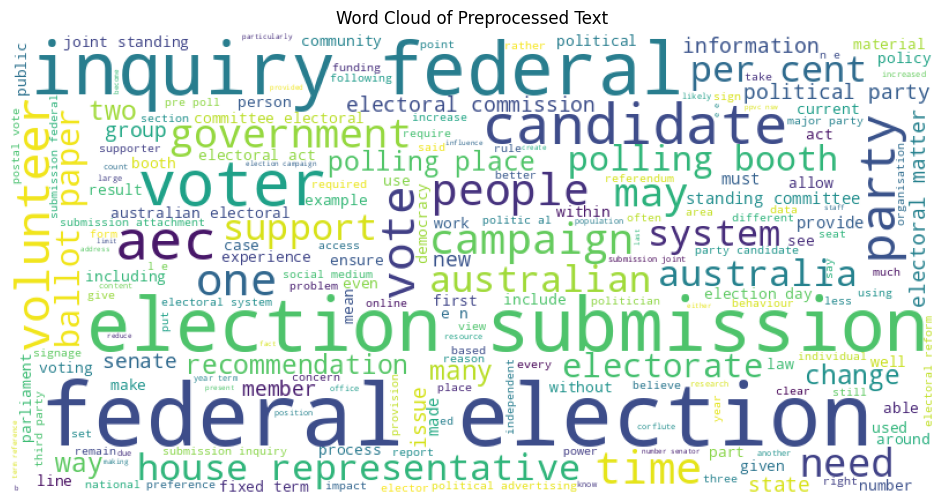

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(processed_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Preprocessed Text")
plt.show()

The word cloud presents a visual summary of the most frequent terms in the cleaned corpus. Larger words indicate higher frequency, making it easier to identify the key topics and ideas that appear across the submissions.

### 2. Topic Modelling



* Topic modelling is an unsupervised natural language processing technique used to identify hidden thematic structures within a large collection of text documents. One of the most commonly used algorithms for this task is Latent Dirichlet Allocation (LDA). LDA works by analysing patterns of word co-occurrence across documents and grouping words into topics that frequently appear together. Each topic is represented by a set of words with associated probabilities.




## 2.1 Using LDA

* In this analysis, LDA is applied to the cleaned and preprocessed parliamentary submissions in order to identify the dominant topics discussed across the dataset. By examining the most representative words within each topic, it becomes possible to gain insights into the key themes and policy concerns expressed in the submissions.

**Prepare cleaned documents for LDA**

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# preprocess each document separately
documents = []

for text in texts:
    words = text.lower().split()
    cleaned_doc = []

    for word in words:
        # remove punctuation from start and end
        word = word.strip(string.punctuation)

        # keep only alphabetic words and remove stopwords
        if word.isalpha() and len(word) > 2 and word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            cleaned_doc.append(lemma)

    documents.append(cleaned_doc)

# quick check
print("Number of documents:", len(documents))
print("Sample cleaned document:", documents[0][:20])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Number of documents: 299
Sample cleaned document: ['monica', 'sammon', 'committee', 'rep', 'subject', 'inquiry', 'federal', 'election', 'date', 'tuesday', 'september', 'writing', 'make', 'small', 'submission', 'inquiry', 'federal', 'election', 'volunteer', 'alex']


**Create dictionary and Corpus**

In [ ]:
dictionary = corpora.Dictionary(documents)

dictionary.filter_extremes(no_below=3, no_above=0.5)


corpus = [dictionary.doc2bow(doc) for doc in documents]

print("Number of unique tokens:", len(dictionary))
print("Number of documents in corpus:", len(corpus))

Number of unique tokens: 6210
Number of documents in corpus: 299


**Train LDA Model**

In [ ]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=15,
    random_state=42
)

topics = lda_model.print_topics(num_words=10)

for topic in topics:
    print(topic)

(0, '0.012*"volunteer" + 0.006*"behaviour" + 0.005*"place" + 0.005*"medium" + 0.004*"material" + 0.004*"including" + 0.004*"term" + 0.004*"advertising" + 0.004*"conduct" + 0.004*"information"')
(1, '0.009*"donation" + 0.008*"independent" + 0.008*"per" + 0.007*"reform" + 0.007*"act" + 0.007*"cap" + 0.007*"funding" + 0.007*"cent" + 0.006*"new" + 0.006*"law"')
(2, '0.020*"ppvc" + 0.015*"volunteer" + 0.009*"nsw" + 0.007*"division" + 0.006*"state" + 0.005*"behaviour" + 0.004*"vic" + 0.004*"total" + 0.004*"per" + 0.004*"experience"')
(3, '0.014*"ballot" + 0.010*"paper" + 0.010*"preference" + 0.008*"value" + 0.008*"system" + 0.006*"count" + 0.005*"result" + 0.005*"nsw" + 0.005*"electorate" + 0.005*"jscem"')
(4, '0.015*"senate" + 0.014*"house" + 0.012*"senator" + 0.012*"term" + 0.011*"state" + 0.010*"parliament" + 0.009*"system" + 0.009*"representative" + 0.009*"per" + 0.008*"year"')


In [ ]:
for i, topic in lda_model.show_topics(num_topics=5, num_words=10, formatted=False):
    print(f"\nTopic {i+1}:")
    print(", ".join([word for word, prob in topic]))


Topic 1:
volunteer, behaviour, place, medium, material, including, term, advertising, conduct, information

Topic 2:
donation, independent, per, reform, act, cap, funding, cent, new, law

Topic 3:
ppvc, volunteer, nsw, division, state, behaviour, vic, total, per, experience

Topic 4:
ballot, paper, preference, value, system, count, result, nsw, electorate, jscem

Topic 5:
senate, house, senator, term, state, parliament, system, representative, per, year


**Results**

The LDA topic modelling results show that the parliamentary submissions cover several distinct themes related to the conduct of the election. Each topic is represented by a group of words that frequently appear together, which helps identify the main issues discussed across the corpus.

* Topic 1 includes words such as volunteer, behaviour, place, material, advertising, conduct, and information. This topic appears to focus on campaign conduct, election materials, and the behaviour of volunteers or campaign representatives at polling places.

* Topic 2 contains terms such as donation, independent, reform, act, cap, funding, cent, and law. This suggests a strong focus on political donations, campaign finance, legislative reform, and funding limits within the electoral system.

* Topic 3 includes words such as ppvc, volunteer, nsw, division, state, behaviour, vic, and experience. This topic seems to relate to polling place operations and voter or volunteer experiences across different Australian states, especially New South Wales and Victoria. Although some abbreviations remain, the topic still reflects election administration and on-ground experiences.

* Topic 4 contains words such as ballot, paper, preference, value, system, count, result, and electorate. This topic is clearly associated with ballot design, vote counting, electoral systems, and preference-based voting processes.

* Topic 5 includes words such as senate, house, senator, parliament, representative, system, and year. This topic appears to focus on parliamentary structure, representation, and the broader electoral framework involving the Senate and House of Representatives.

The identified topics suggest that many submissions focus on issues related to electoral processes, governance structures, and administrative procedures. For example, one topic contains words such as senate, parliament, representative, and state, indicating discussions around political institutions and representation. Another topic contains terms such as donation, reform, and law, which may relate to discussions around electoral regulations and campaign finance.

Overall, the topic modelling results suggest that the submissions mainly discuss campaign behaviour, political funding and reform, polling-place experiences, ballot and counting systems, and parliamentary representation. These themes are consistent with the nature of a parliamentary inquiry into the conduct of a federal election and show that contributors were concerned with both practical election processes and broader democratic reforms.

 **Advantages**

Topic modelling is useful because it can automatically discover hidden themes within a large collection of text documents without requiring manual labelling. This makes it particularly suitable for analysing large datasets such as parliamentary submissions where reading each document individually would be time-consuming. The method groups words that frequently occur together, allowing researchers to quickly identify the dominant issues discussed across the corpus. In addition, topic modelling helps summarise complex textual information into a smaller number of interpretable topics, which makes it easier to understand the overall structure of the dataset.

**Limitations of Topic Modelling**

Despite its usefulness, topic modelling also has several limitations. The interpretation of topics is subjective, as the algorithm only provides groups of words and the researcher must determine what the topic represents. The results are also highly dependent on preprocessing quality, such as stopword removal and text cleaning. If the text contains noise, abbreviations, or irrelevant tokens, the topics may become less meaningful. Furthermore, the number of topics must be chosen manually, and selecting too many or too few topics can affect the clarity and interpretability of the results.

## 2.2 Clustering using K-Means

Clustering is an unsupervised machine learning technique used to group similar documents based on shared patterns in their textual content. In this analysis, K-Means clustering was applied to the parliamentary submissions in order to identify groups of documents that are similar to each other. Unlike topic modelling, which focuses on discovering latent themes through word co-occurrence, clustering groups entire documents based on their overall textual similarity.

To apply K-Means, the text documents were first transformed into numerical features using TF-IDF (Term Frequency–Inverse Document Frequency). TF-IDF gives higher importance to words that are frequent in a document but less common across the full dataset, making it useful for distinguishing documents based on meaningful terms. The K-Means algorithm then partitions the documents into a chosen number of clusters by minimizing the distance between documents and their assigned cluster centres.

**Convert documents into TF-IDF features**

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(texts)

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (299, 1000)


**Apply K-Means Clustering**

In [ ]:
num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(X)

clusters = kmeans.labels_

print("Cluster labels assigned to documents:")
print(clusters[:20])

Cluster labels assigned to documents:
[3 2 3 0 2 3 3 3 1 3 1 2 4 2 3 2 4 1 3 0]


**Count documents in each cluster**

In [ ]:
cluster_df = pd.DataFrame({
    "document_id": range(len(texts)),
    "cluster": clusters
})

cluster_counts = cluster_df["cluster"].value_counts().sort_index()
print(cluster_counts)

cluster
0    26
1    90
2    70
3    64
4    49
Name: count, dtype: int64


The cluster distribution shows how many submissions fall into each cluster. This helps determine whether the data is evenly distributed across groups or whether some themes dominate the corpus.

**Visualize cluster size**

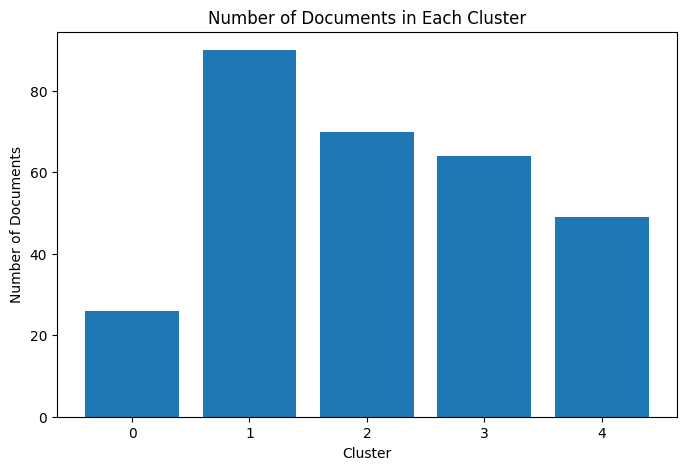

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Number of Documents in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Documents")
plt.show()

**Top terms in each cluster**

In [ ]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(num_clusters):
    print(f"\nCluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_terms))


Cluster 0:
submission, 2025, election, federal, inquiry, 52, 79, 57, 77, 72

Cluster 1:
polling, election, volunteers, voters, 2025, party, booth, aec, candidate, voting

Cluster 2:
volunteers, election, 2025, booth, federal, volunteer, submission, pre, voters, church

Cluster 3:
election, electoral, 2025, political, federal, submission, public, australia, aec, inquiry

Cluster 4:
senate, election, senators, house, 2025, parliament, number, terms, representatives, electoral


**Results**

The K-Means clustering results group the submissions into several clusters based on their textual similarity. Each cluster contains documents that use similar vocabulary and therefore likely discuss related issues. By examining the top terms associated with each cluster, it becomes possible to interpret the general focus of the documents within that group.

For example, one cluster may contain terms related to electoral reform, while another may focus more on administration, voting procedures, or policy concerns. The cluster size chart also shows whether the submissions are evenly distributed across groups or whether certain types of discussions are more dominant in the corpus.

Compared with topic modelling, clustering provides a document-level grouping rather than a theme-level summary. This means it is useful for understanding how submissions can be separated into broad categories of similar responses.

**Advantages of K-Means Clustering**

One advantage of K-Means clustering is that it groups whole documents according to their similarity, making it easier to identify broad categories of submissions. It is also relatively simple to implement and computationally efficient for medium-sized text datasets. When combined with TF-IDF features, clustering can provide a useful way to explore hidden structure within a large set of documents.

**Limitation of K-Means Clustering**

A limitation of K-Means clustering is that the number of clusters must be chosen in advance, which may affect the quality and interpretability of the results. In addition, the algorithm assigns each document to only one cluster, even though some submissions may discuss multiple issues at the same time. The results can also be sensitive to the feature representation and preprocessing choices. For this reason, clustering should be interpreted as an exploratory technique rather than a definitive classification.

**Comparison between Topic Modelling and Clustering**

Topic modelling and clustering provide different but complementary perspectives on the dataset. Topic modelling identifies recurring themes by analysing patterns of word co-occurrence, which helps summarise the key issues discussed across all submissions. In contrast, clustering groups entire documents according to their textual similarity, making it possible to identify broad categories of submissions. Topic modelling is more suitable for understanding themes and concepts, while clustering is more useful for grouping documents into similar sets. Both methods are exploratory in nature, and their results depend on preprocessing choices and parameter settings. Using both approaches together provides a more complete understanding of the structure and content of the parliamentary submissions.

### Conclusion



This analysis explored the parliamentary submissions dataset using several text analysis techniques. The initial exploratory analysis examined basic characteristics of the text, including word frequencies, word length distributions, and document length distributions. These visualisations provided a general overview of the vocabulary and structure of the submissions and helped identify commonly used terms across the dataset.

Topic modelling using the LDA algorithm was then applied to identify underlying themes within the corpus. The results revealed several meaningful topic groups, including themes related to electoral processes, governance, voting systems, and political participation. By examining the most important words within each topic, it was possible to interpret the key issues discussed across the submissions.

In addition, clustering techniques were used to group similar submissions together based on textual similarity. This approach helped identify groups of documents that shared similar vocabulary and likely discussed related concerns or policy issues.

Overall, the combination of exploratory analysis, topic modelling, and clustering provided both surface-level and deeper insights into the dataset. While frequency analysis helped understand the most common vocabulary, topic modelling and clustering revealed broader themes and relationships between documents. Future work could further improve the analysis by applying advanced natural language processing techniques such as sentiment analysis, word embeddings, or transformer-based models to better capture semantic relationships within the submissions.
These insights can help policymakers and researchers better understand the concerns and perspectives expressed in public submissions.

### References

Bird, S., Klein, E., & Loper, E. (2009). Natural Language Processing with Python. O'Reilly Media.

Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet Allocation. Journal of Machine Learning Research, 3, 993–1022.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Rehurek, R., & Sojka, P. (2010). Gensim – Topic modelling for humans. Proceedings of the LREC Workshop on New Challenges for NLP Frameworks.